In [3]:
from mesa import *
from mesa.discrete_space import OrthogonalVonNeumannGrid
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

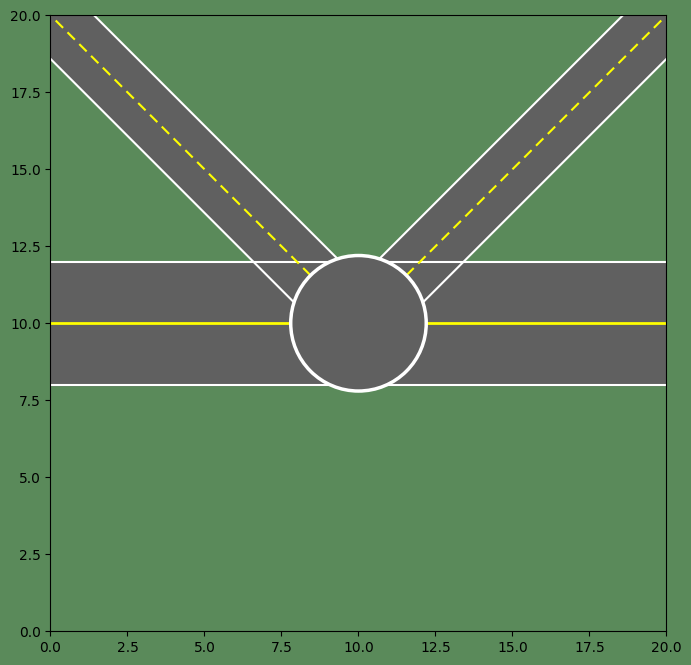

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def street_polygon(cx, cy, angle_deg, half_width, length):
    """Returns polygon vertices for a road strip from center in angle_deg direction."""
    a = np.radians(angle_deg)
    dx, dy = np.cos(a), np.sin(a)
    px, py = -np.sin(a), np.cos(a)
    x0, y0 = cx, cy
    x1, y1 = cx + length * dx, cy + length * dy
    return [
        (x0 + half_width * px, y0 + half_width * py),
        (x0 - half_width * px, y0 - half_width * py),
        (x1 - half_width * px, y1 - half_width * py),
        (x1 + half_width * px, y1 + half_width * py),
    ]


def draw_intersection(width=20, height=20):
    fig, ax = plt.subplots(figsize=(10, 8))

    grass_color = '#5a8a5a'
    road_color  = '#606060'
    ax.set_facecolor(grass_color)
    fig.patch.set_facecolor(grass_color)

    cx, cy = width / 2, height / 2
    r      = 2.2   # circle (plaza) radius
    ave_hw = 2.0   # half-width of full avenue (both lanes together)
    st_hw  = 1.0   # half-width of each side street
    L      = max(width, height) + 5  # extend roads safely past canvas

    # ── Road surfaces ──────────────────────────────────────────────────────
    # Main avenue (full horizontal band, west→east)
    ax.add_patch(plt.Polygon([
        (0,     cy - ave_hw), (width, cy - ave_hw),
        (width, cy + ave_hw), (0,     cy + ave_hw),
    ], color=road_color, zorder=1))

    # NW street (135°) and NE street (45°) from center
    for angle in [135, 45]:
        ax.add_patch(plt.Polygon(
            street_polygon(cx, cy, angle, st_hw, L),
            color=road_color, zorder=1
        ))

    # ── Lane markings (zorder=2, circle will cover center portion) ─────────
    # Avenue: solid yellow center divider (dedicated lanes, no crossing)
    ax.plot([0, width], [cy, cy], color='yellow', linewidth=2, zorder=2)
    # Avenue: white edge lines
    for ye in [cy - ave_hw, cy + ave_hw]:
        ax.plot([0, width], [ye, ye], color='white', linewidth=1.5, zorder=2)

    # Side streets: markings start from circle edge outward
    for angle in [135, 45]:
        a = np.radians(angle)
        dx, dy = np.cos(a), np.sin(a)
        px, py = -np.sin(a), np.cos(a)

        xs, ys = cx + r * dx, cy + r * dy   # start at circle edge
        xe, ye = cx + L * dx, cy + L * dy   # extend to canvas edge

        # Yellow dashed center line (bidirectional street)
        ax.plot([xs, xe], [ys, ye], color='yellow', linewidth=1.5,
                linestyle='--', dashes=(5, 3), zorder=2)
        # White edge lines
        for side in [1, -1]:
            ax.plot(
                [cx + side * st_hw * px, xe + side * st_hw * px],
                [cy + side * st_hw * py, ye + side * st_hw * py],
                color='white', linewidth=1.5, zorder=2
            )

    # ── Center circle (plaza — not a roundabout) ───────────────────────────
    ax.add_patch(mpatches.Circle((cx, cy), r, color=road_color, zorder=3))
    ax.add_patch(mpatches.Circle((cx, cy), r, color='white', fill=False,
                                  linewidth=2.5, zorder=4))

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.set_axis_off() 
    return fig, ax


fig, ax = draw_intersection(20, 20)
plt.show()
